# Contributor Compass — Data Analysis & Visualization

**Question.** Is a repository's popularity a good proxy for how welcoming it is to
new contributors? And can we build a better measure?

Existing tools (goodfirstissue.dev, up-for-grabs, CodeTriage) list beginner-friendly
*issues*. None of them tell you whether anyone will actually review your pull request.
This notebook builds a **Contributor-Friendliness Index** from GitHub data and tests
whether stars predict anything a newcomer cares about.

**Data.** Collected from the GitHub GraphQL API as a single dated snapshot, stratified
across 8 languages and 5 star buckets. See `collect.py` for acquisition and `build.py`
for the metric layer.

| Section | Practical |
|---|---|
| 1. Cleaning & preprocessing | P1 |
| 2. Exploratory data analysis | P2 |
| 3. Statistical testing | P3 |
| 4. Time series & forecasting | P4 |
| 5. Geospatial mapping | P5 |
| 6. ML model visualization | P7 |
| Dashboard (`app.py`) | P6 |
| End-to-end pipeline | P8 |

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

DATA = Path("..") / "data"

# The palette is the one validated for the dashboard: colourblind-safe on a
# light surface, checked with the data-viz palette validator.
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK_2, MUTED, GRID = "#0b0b0b", "#52514e", "#898781", "#e1e0d9"
SURFACE = "#fcfcfb"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": INK_2,
    "text.color": INK, "xtick.color": MUTED, "ytick.color": MUTED,
    "grid.color": GRID, "axes.grid": True, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.family": "sans-serif", "font.size": 11, "figure.dpi": 110,
})

repos = pd.read_csv(DATA / "repos.csv")
prs = pd.read_csv(DATA / "prs.csv", parse_dates=["created_at", "merged_at", "closed_at"])
issues = pd.read_csv(DATA / "issues.csv", parse_dates=["created_at", "closed_at"])

print(f"repos  {repos.shape[0]:>6} rows x {repos.shape[1]} cols")
print(f"prs    {prs.shape[0]:>6} rows")
print(f"issues {issues.shape[0]:>6} rows")
print(f"total  {len(repos) + len(prs) + len(issues):>6} rows")

repos     519 rows x 52 cols
prs     18384 rows
issues  21391 rows
total   40294 rows


---
## 1. Data cleaning and preprocessing

Three cleaning decisions matter here, and each one is defensible rather than routine.

### 1.1 Bot removal

CHAOSS states explicitly that **Time to First Response and Change Request Closure Ratio
are only meaningful when the activity is human-driven**. Dependabot, Renovate,
`github-actions[bot]` and Codecov open pull requests and comment on issues constantly.
Leaving them in would make an unresponsive repo look attentive: a bot replying in
30 seconds would register as a 30-second "first response".

Bots were filtered at the metric layer (`build.py`), before any timing was computed.

In [2]:
import re
BOT = re.compile(r"(\[bot\]$|^dependabot|^renovate|^github-actions|^codecov"
                 r"|^mergify|^stale|^pre-commit-ci|-bot$)", re.I)

# Verify the filter actually held: no bot-authored rows should survive.
leaked = prs[prs["author"].fillna("").str.contains(BOT)]
print(f"bot-authored PRs remaining after filtering: {len(leaked)}")

# What the filter removed, measured on the raw dump:
import json
raw_authors, kept_authors = [], set(prs["author"].dropna())
with open(DATA / "raw.jsonl") as f:
    for line in f:
        repo = json.loads(line)
        for pr in (repo.get("prs") or {}).get("nodes") or []:
            if pr and pr.get("author"):
                raw_authors.append(pr["author"]["login"])

bots = sorted({a for a in raw_authors if BOT.search(a)})
print(f"distinct bot accounts found in the raw dump: {len(bots)}")
print("examples:", bots[:8])
print(f"share of raw PRs authored by bots: {sum(1 for a in raw_authors if BOT.search(a)) / len(raw_authors):.1%}")

bot-authored PRs remaining after filtering: 0


distinct bot accounts found in the raw dump: 30
examples: ['adop1344-bot', 'astral-automations-bot', 'coral-release-bot', 'dependabot', 'dependabot-preview', 'dlp-bot', 'github-actions', 'github-security-bot']
share of raw PRs authored by bots: 15.1%


### 1.2 Missing values

Missingness here is **structural, not random** — a repo with no closed pull requests
cannot have a merge rate. Imputing a value would invent data, so these stay `NaN` and
are excluded pairwise from each statistic.

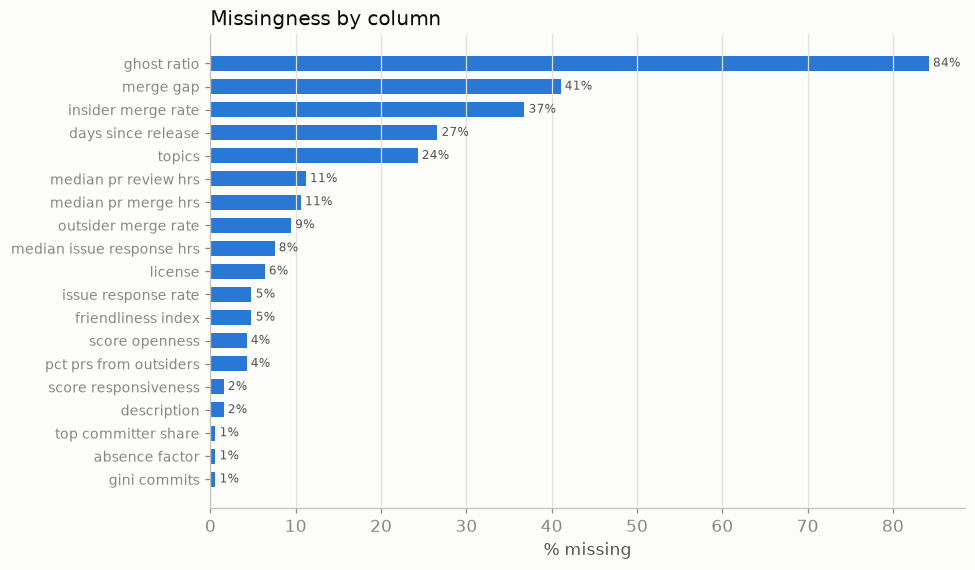

median_issue_response_hrs    39
outsider_merge_rate          49
gini_commits                  3
dtype: int64


In [3]:
miss = (repos.isna().mean() * 100).sort_values(ascending=False)
miss = miss[miss > 0]

fig, ax = plt.subplots(figsize=(9, max(3, len(miss) * 0.28)))
ax.barh(range(len(miss)), miss.values, color=BLUE, height=0.65)
ax.set_yticks(range(len(miss)))
ax.set_yticklabels([i.replace("_", " ") for i in miss.index], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("% missing")
ax.set_title("Missingness by column", loc="left", color=INK, fontsize=13)
for i, v in enumerate(miss.values):
    ax.text(v + 0.5, i, f"{v:.0f}%", va="center", fontsize=8, color=INK_2)
ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

print(repos[["median_issue_response_hrs", "outsider_merge_rate", "gini_commits"]].isna().sum())

### 1.3 Outliers

Response times are heavily right-skewed — most issues get an answer in hours, a few
sit for months. That shape is **real signal, not error**: a repo that takes 4,000 hours
to reply is genuinely unresponsive. So outliers are kept, and the analysis uses
**medians and rank-based tests** rather than means and t-tests.

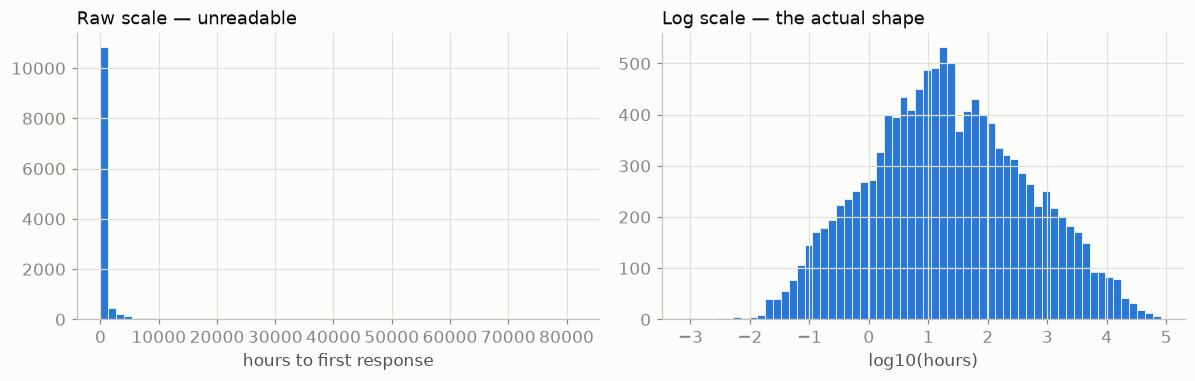

skewness          9.97
mean             853.7 h
median            18.8 h   <- the honest summary
95th pct        3865.5 h


In [4]:
h = issues["hours_to_first_response"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].hist(h, bins=60, color=BLUE, edgecolor=SURFACE, linewidth=0.5)
axes[0].set_title("Raw scale — unreadable", loc="left", color=INK, fontsize=12)
axes[0].set_xlabel("hours to first response")

axes[1].hist(np.log10(h[h > 0]), bins=60, color=BLUE, edgecolor=SURFACE, linewidth=0.5)
axes[1].set_title("Log scale — the actual shape", loc="left", color=INK, fontsize=12)
axes[1].set_xlabel("log10(hours)")
plt.tight_layout(); plt.show()

print(f"skewness      {stats.skew(h):8.2f}")
print(f"mean          {h.mean():8.1f} h")
print(f"median        {h.median():8.1f} h   <- the honest summary")
print(f"95th pct      {h.quantile(.95):8.1f} h")

### 1.4 Feature engineering

The metrics that matter are not returned by the API — they are derived.

| Derived feature | How |
|---|---|
| `outsider_merge_rate` | merged ÷ resolved PRs where `author_association` ∈ {CONTRIBUTOR, FIRST_TIMER, NONE} |
| `merge_gap` | insider merge rate − outsider merge rate |
| `ghost_ratio` | share of open good-first-issues that are unassigned **and** untouched 90+ days |
| `gini_commits` | inequality of commits per contributor |
| `absence_factor` | CHAOSS: smallest group producing 50% of commits |
| `score_*` | percentile **within language × size bucket** |

In [5]:
derived = ["outsider_merge_rate", "insider_merge_rate", "merge_gap", "ghost_ratio",
           "gini_commits", "absence_factor", "commits_per_week", "friendliness_index"]
repos[derived].describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
outsider_merge_rate,470.0,0.608,0.322,0.000,0.366,0.700,0.871,1.00
insider_merge_rate,328.0,0.901,0.211,0.000,0.912,1.000,1.000,1.00
merge_gap,306.0,0.273,0.341,-0.844,0.000,0.230,0.496,1.00
ghost_ratio,82.0,0.488,0.416,0.000,0.000,0.448,1.000,1.00
gini_commits,516.0,0.537,0.229,0.000,0.468,0.607,0.698,0.81
absence_factor,516.0,2.060,3.035,1.000,1.000,1.000,2.000,32.00
commits_per_week,519.0,37.648,116.605,0.010,0.655,3.230,17.745,700.00
friendliness_index,494.0,52.264,9.472,24.800,44.950,52.550,59.175,77.10


---
## 2. Exploratory data analysis

In [6]:
summary = repos[["stars", "forks", "age_years", "open_issues", "open_prs",
                 "median_issue_response_hrs", "outsider_merge_rate",
                 "unique_committers", "gini_commits"]].describe().T
summary["skew"] = [stats.skew(repos[c].dropna()) for c in summary.index]
summary.round(2)

,count,mean,std,min,25%,50%,75%,max,skew
stars,519.0,32397.23,66621.76,199.00,995.00,4965.00,19629.00,482387.00,3.34
forks,519.0,5358.01,12552.85,0.00,89.00,587.00,3061.50,108440.00,3.77
age_years,519.0,7.74,4.87,0.05,3.42,8.18,11.52,18.54,0.05
open_issues,519.0,429.67,1737.54,0.00,4.00,34.00,174.00,18526.00,7.47
open_prs,519.0,182.93,1397.20,0.00,1.00,10.00,50.50,30110.00,19.27
median_issue_response_hrs,480.0,231.80,1102.37,0.03,6.64,21.74,96.71,20313.41,13.88
outsider_merge_rate,470.0,0.61,0.32,0.00,0.37,0.70,0.87,1.00,-0.61
unique_committers,519.0,12.82,13.18,0.00,3.00,9.00,18.00,80.00,1.95
gini_commits,516.0,0.54,0.23,0.00,0.47,0.61,0.70,0.81,-1.26


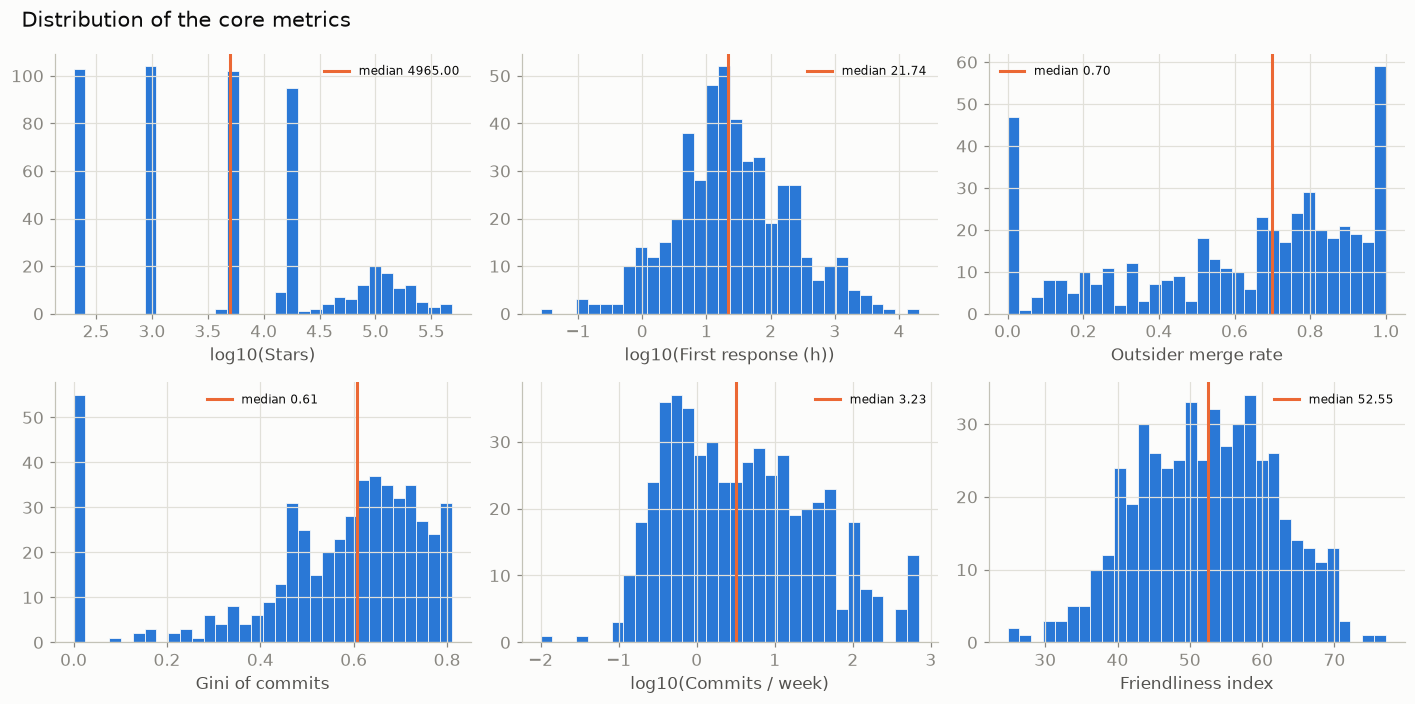

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(13, 6.5))
specs = [
    ("stars", "Stars", True), ("median_issue_response_hrs", "First response (h)", True),
    ("outsider_merge_rate", "Outsider merge rate", False),
    ("gini_commits", "Gini of commits", False),
    ("commits_per_week", "Commits / week", True),
    ("friendliness_index", "Friendliness index", False),
]
for ax, (col, label, logx) in zip(axes.flat, specs):
    d = repos[col].dropna()
    if logx:
        d = d[d > 0]
        ax.hist(np.log10(d), bins=32, color=BLUE, edgecolor=SURFACE, linewidth=0.5)
        ax.set_xlabel(f"log10({label})")
    else:
        ax.hist(d, bins=32, color=BLUE, edgecolor=SURFACE, linewidth=0.5)
        ax.set_xlabel(label)
    ax.axvline(np.log10(d.median()) if logx else d.median(),
               color=ORANGE, linewidth=2, label=f"median {d.median():.2f}")
    ax.legend(fontsize=8, frameon=False)
fig.suptitle("Distribution of the core metrics", x=0.02, ha="left", fontsize=14, color=INK)
plt.tight_layout(); plt.show()

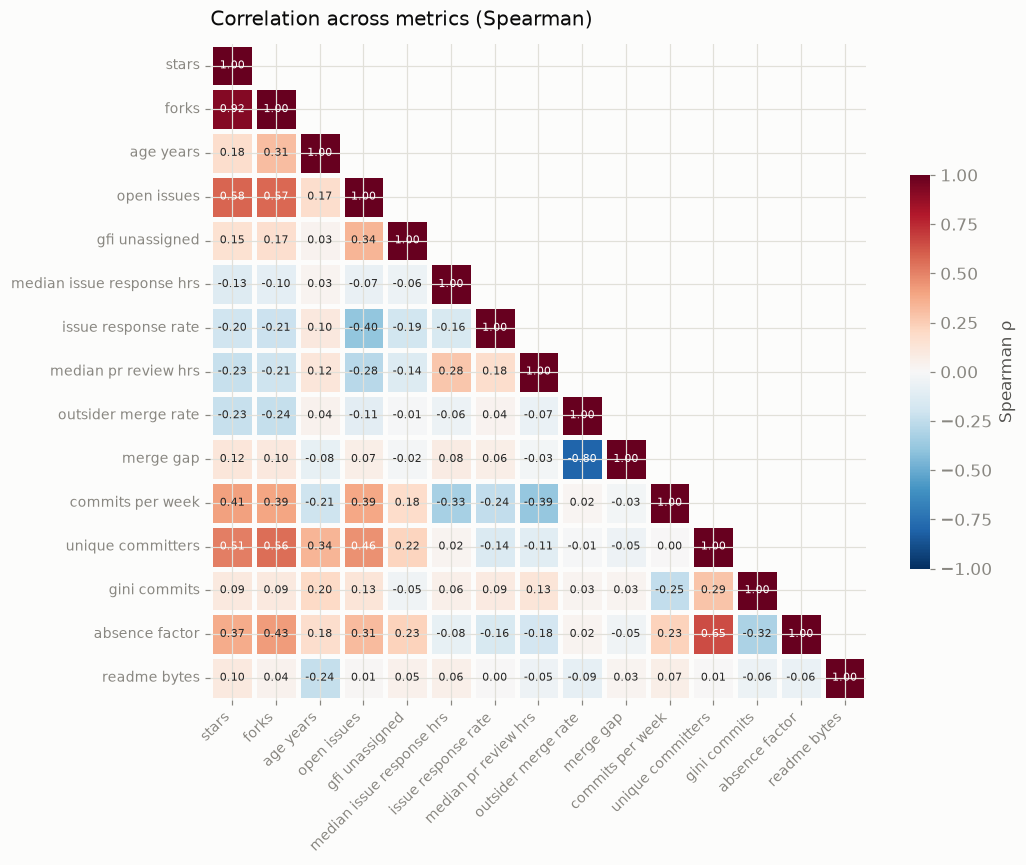

In [8]:
cols = ["stars", "forks", "age_years", "open_issues", "gfi_unassigned",
        "median_issue_response_hrs", "issue_response_rate", "median_pr_review_hrs",
        "outsider_merge_rate", "merge_gap", "commits_per_week", "unique_committers",
        "gini_commits", "absence_factor", "readme_bytes"]
corr = repos[cols].corr(method="spearman")

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, linewidths=2, linecolor=SURFACE,
            cbar_kws={"shrink": .6, "label": "Spearman ρ"},
            annot=True, fmt=".2f", annot_kws={"size": 7}, ax=ax)
ax.set_title("Correlation across metrics (Spearman)", loc="left", color=INK, fontsize=13, pad=12)
ax.set_xticklabels([t.get_text().replace("_", " ") for t in ax.get_xticklabels()],
                   rotation=45, ha="right", fontsize=9)
ax.set_yticklabels([t.get_text().replace("_", " ") for t in ax.get_yticklabels()],
                   rotation=0, fontsize=9)
plt.tight_layout(); plt.show()

**Read the `stars` row.** If popularity were a proxy for a good contributor experience,
`stars` would correlate with responsiveness and merge rate. It does not.

---
## 3. Statistical testing

Every test below is **rank-based**, because section 1.3 established that the
distributions are heavily right-skewed. A t-test would assume normality that the
data does not have.

### 3.1 Does a CONTRIBUTING.md predict a faster first response?

with CONTRIBUTING.md     n=237  median    19.5 h
without                  n=243  median    26.0 h

Mann-Whitney U = 24,816   p = 0.008822
rank-biserial effect size = 0.138

REJECT the null at alpha = 0.05


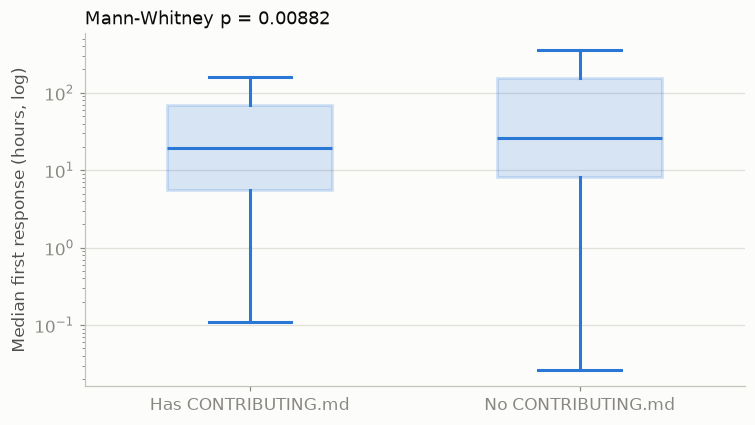

In [9]:
with_c = repos[repos["has_contributing"]]["median_issue_response_hrs"].dropna()
without_c = repos[~repos["has_contributing"]]["median_issue_response_hrs"].dropna()

u, p = stats.mannwhitneyu(with_c, without_c, alternative="two-sided")
# Rank-biserial correlation as the effect size (Mann-Whitney's natural companion).
effect = 1 - (2 * u) / (len(with_c) * len(without_c))

print(f"with CONTRIBUTING.md     n={len(with_c):3}  median {with_c.median():7.1f} h")
print(f"without                  n={len(without_c):3}  median {without_c.median():7.1f} h")
print(f"\nMann-Whitney U = {u:,.0f}   p = {p:.4g}")
print(f"rank-biserial effect size = {effect:.3f}")
print(f"\n{'REJECT' if p < 0.05 else 'FAIL TO REJECT'} the null at alpha = 0.05")

fig, ax = plt.subplots(figsize=(7, 4))
data = [with_c, without_c]
bp = ax.boxplot(data, patch_artist=True, widths=0.5, showfliers=False,
                tick_labels=["Has CONTRIBUTING.md", "No CONTRIBUTING.md"])
for patch in bp["boxes"]:
    patch.set(facecolor=BLUE, alpha=0.18, edgecolor=BLUE, linewidth=2)
for part in ["whiskers", "caps", "medians"]:
    for line in bp[part]:
        line.set(color=BLUE, linewidth=2)
ax.set_yscale("log")
ax.set_ylabel("Median first response (hours, log)")
ax.set_title(f"Mann-Whitney p = {p:.3g}", loc="left", color=INK, fontsize=12)
ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

### 3.2 Does responsiveness differ across languages?

In [10]:
groups, names = [], []
for lang, g in repos.groupby("language"):
    vals = g["median_issue_response_hrs"].dropna()
    if len(vals) >= 5:
        groups.append(vals.values); names.append(lang)

h, p = stats.kruskal(*groups)
print(f"Kruskal-Wallis H = {h:.2f}   p = {p:.4g}   across {len(groups)} languages\n")
for n, g in sorted(zip(names, groups), key=lambda x: np.median(x[1])):
    print(f"  {n:12} n={len(g):3}  median {np.median(g):7.1f} h")

print(f"\n{'Languages differ significantly' if p < 0.05 else 'No significant difference'} "
      "-> justifies ranking repos within their own language, not globally.")

Kruskal-Wallis H = 19.40   p = 0.007019   across 8 languages

  C++          n= 57  median    15.3 h
  Rust         n= 62  median    17.0 h
  Go           n= 64  median    20.5 h
  Java         n= 62  median    20.5 h
  TypeScript   n= 56  median    25.1 h
  Python       n= 60  median    27.9 h
  Ruby         n= 58  median    37.3 h
  JavaScript   n= 61  median    40.4 h

Languages differ significantly -> justifies ranking repos within their own language, not globally.


### 3.3 Chi-square: is having a contributing guide associated with merging outsiders?

In [11]:
d = repos.dropna(subset=["outsider_merge_rate"]).copy()
d["welcoming"] = d["outsider_merge_rate"] > d["outsider_merge_rate"].median()
table = pd.crosstab(d["has_contributing"], d["welcoming"])
table.index = ["No CONTRIBUTING", "Has CONTRIBUTING"]
table.columns = ["Below median", "Above median"]

chi2, p, dof, expected = stats.chi2_contingency(table)
n = table.values.sum()
cramers_v = np.sqrt(chi2 / (n * (min(table.shape) - 1)))

print(table, "\n")
print(f"chi2 = {chi2:.3f}   dof = {dof}   p = {p:.4g}   Cramer's V = {cramers_v:.3f}")
print(f"\n{'Associated' if p < 0.05 else 'No detectable association'} at alpha = 0.05")

                  Below median  Above median
No CONTRIBUTING            115           122
Has CONTRIBUTING           122           111 

chi2 = 0.547   dof = 1   p = 0.4595   Cramer's V = 0.034

No detectable association at alpha = 0.05


### 3.4 The headline test: do stars predict responsiveness?

stars vs responsiveness      rho = +0.009   p = 0.8305   n = 511
stars vs outsider merge rate rho = -0.233   p = 3.325e-07


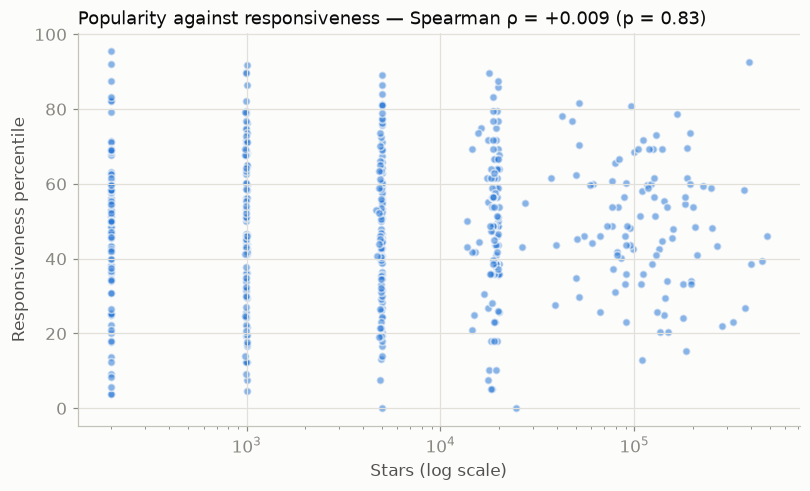

In [12]:
v = repos.dropna(subset=["stars", "score_responsiveness"])
rho, p_rho = stats.spearmanr(v["stars"], v["score_responsiveness"])
rho_m, p_m = stats.spearmanr(
    repos.dropna(subset=["stars", "outsider_merge_rate"])["stars"],
    repos.dropna(subset=["stars", "outsider_merge_rate"])["outsider_merge_rate"])

print(f"stars vs responsiveness      rho = {rho:+.3f}   p = {p_rho:.4g}   n = {len(v)}")
print(f"stars vs outsider merge rate rho = {rho_m:+.3f}   p = {p_m:.4g}")

fig, ax = plt.subplots(figsize=(7.5, 4.6))
ax.scatter(v["stars"], v["score_responsiveness"], s=26, color=BLUE, alpha=0.55,
           edgecolor=SURFACE, linewidth=1.2)
ax.set_xscale("log")
ax.set_xlabel("Stars (log scale)")
ax.set_ylabel("Responsiveness percentile")
ax.set_title(f"Popularity against responsiveness — Spearman ρ = {rho:+.3f} (p = {p_rho:.3g})",
             loc="left", color=INK, fontsize=12)
plt.tight_layout(); plt.show()

### 3.5 Logistic regression: the insider–outsider merge gap

In [13]:
import statsmodels.api as sm

d = prs[prs["is_resolved"]].copy()
d["outsider"] = d["is_outsider"].astype(int)
d["log_size"] = np.log1p(d["additions"].fillna(0) + d["deletions"].fillna(0))

X = sm.add_constant(d[["outsider", "log_size"]].astype(float))
model = sm.Logit(d["is_merged"].astype(int), X).fit(disp=0)
print(model.summary2().tables[1].round(4))

odds = np.exp(model.params["outsider"])
print(f"\nOdds ratio for being an outsider: {odds:.3f}")
print(f"Holding PR size constant, an outsider's pull request has "
      f"{(1 - odds) * 100:.0f}% lower odds of being merged.")

           Coef.  Std.Err.        z  P>|z|  [0.025  0.975]
const     2.9023    0.0739  39.2612    0.0  2.7575  3.0472
outsider -2.1194    0.0645 -32.8442    0.0 -2.2458 -1.9929
log_size -0.0532    0.0088  -6.0555    0.0 -0.0704 -0.0360

Odds ratio for being an outsider: 0.120
Holding PR size constant, an outsider's pull request has 88% lower odds of being merged.


---
## 4. Time series and forecasting

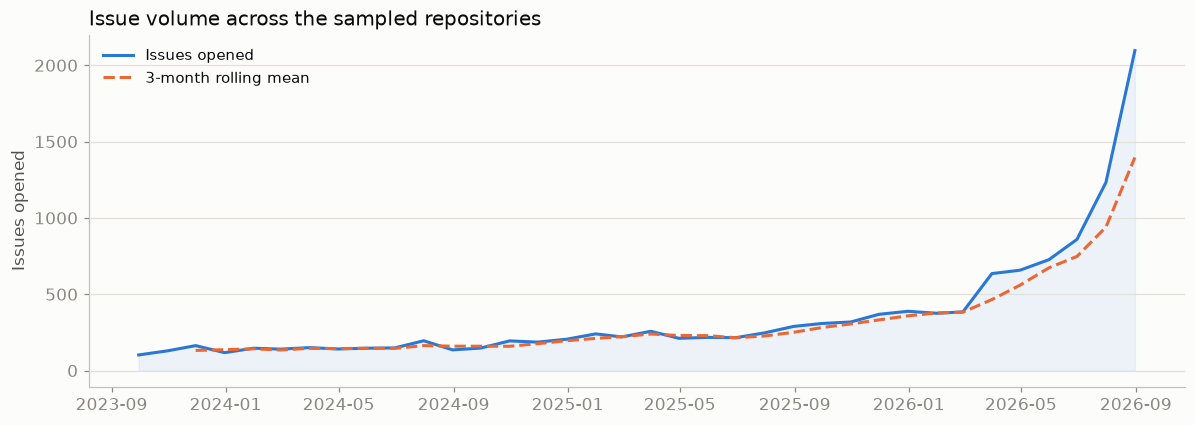

In [14]:
s = issues.set_index("created_at").sort_index()
monthly = s.resample("ME").size()
monthly = monthly[monthly.index >= monthly.index.max() - pd.DateOffset(months=36)]
monthly = monthly.iloc[:-1]  # drop the partial current month

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(monthly.index, monthly.values, color=BLUE, linewidth=2, label="Issues opened")
ax.plot(monthly.index, monthly.rolling(3).mean(), color=ORANGE, linewidth=2,
        linestyle="--", label="3-month rolling mean")
ax.fill_between(monthly.index, 0, monthly.values, color=BLUE, alpha=0.07)
ax.set_title("Issue volume across the sampled repositories", loc="left", color=INK, fontsize=13)
ax.set_ylabel("Issues opened")
ax.legend(frameon=False, fontsize=10)
ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

/Users/amey/Projects/contributor-compass/.venv/lib/python3.11/site-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params


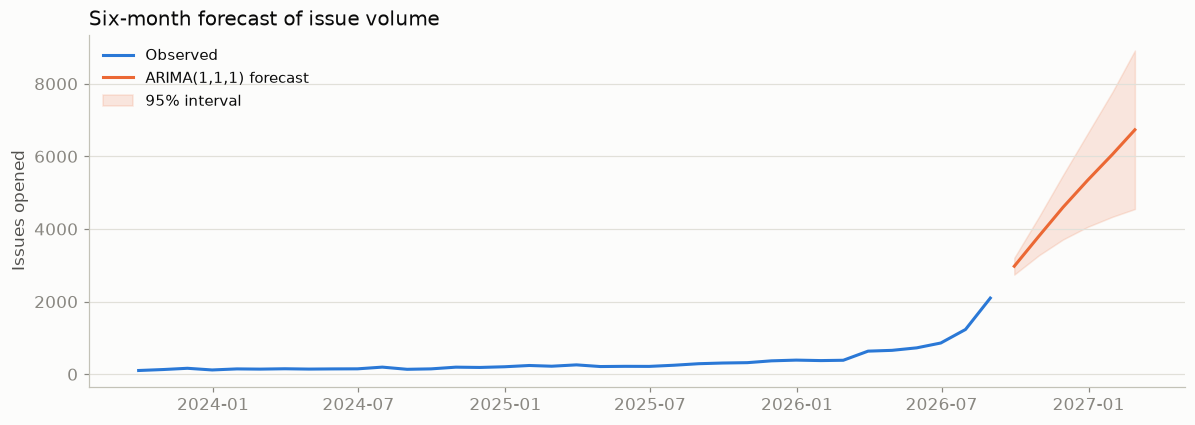

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   36
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -217.662
Date:                Wed, 23 Sep 2026   AIC                            441.324
Time:                        10:34:00   BIC                            445.990
Sample:                    09-30-2023   HQIC                           442.935
                         - 08-31-2026                                         
Covariance Type:                  opg                                         

AIC 441.3   BIC 446.0
Back-test MAPE on the last 6 months: 55.9%


In [15]:
from statsmodels.tsa.arima.model import ARIMA

series = monthly.astype(float)
fit = ARIMA(series, order=(1, 1, 1)).fit()
steps = 6
fc = fit.get_forecast(steps=steps)
mean, ci = fc.predicted_mean, fc.conf_int()
future = pd.date_range(series.index[-1] + pd.offsets.MonthEnd(), periods=steps, freq="ME")

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(series.index, series.values, color=BLUE, linewidth=2, label="Observed")
ax.plot(future, mean.values, color=ORANGE, linewidth=2, label="ARIMA(1,1,1) forecast")
ax.fill_between(future, ci.iloc[:, 0], ci.iloc[:, 1], color=ORANGE, alpha=0.15,
                label="95% interval")
ax.set_title("Six-month forecast of issue volume", loc="left", color=INK, fontsize=13)
ax.set_ylabel("Issues opened")
ax.legend(frameon=False, fontsize=10)
ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

print(fit.summary().tables[0])
print(f"\nAIC {fit.aic:.1f}   BIC {fit.bic:.1f}")

# In-sample accuracy on the last 6 observed months.
back = ARIMA(series[:-6], order=(1, 1, 1)).fit()
pred = back.forecast(6)
mape = np.mean(np.abs((series[-6:].values - pred.values) / series[-6:].values)) * 100
print(f"Back-test MAPE on the last 6 months: {mape:.1f}%")

**Caveat.** This aggregates issue volume across the whole sample, so it measures the
activity of the sampled cohort, not any single project. The upward drift partly reflects
GitHub's overall growth rather than these repos specifically.

---
## 5. Geospatial mapping

GitHub normalises every commit timestamp to UTC, so the original git timezone offset
is not recoverable from the API. Profile location is the workable route — and it is
free text, which makes normalising it a genuine cleaning problem.

In [16]:
contrib = pd.read_csv(DATA / "contributors.csv")
print(f"contributors looked up : {len(contrib):,}")
print(f"with a location string : {contrib['location_raw'].notna().sum():,}")
print(f"resolved to a country  : {contrib['country'].notna().sum():,}")
print()
print("Examples of what had to be parsed:")
for raw in contrib["location_raw"].dropna().sample(min(10, contrib['location_raw'].notna().sum()),
                                                   random_state=1):
    country = contrib[contrib["location_raw"] == raw]["country"].iloc[0]
    print(f"   {str(raw)[:38]:40} -> {country}")

contributors looked up : 1,898
with a location string : 670
resolved to a country  : 563

Examples of what had to be parsed:
   Madison, WI                              -> nan
   Paris, France                            -> France
   Austria                                  -> Austria
   Belgium                                  -> Belgium
   Moscow                                   -> Russia
   San Diego, CA                            -> United States
   United States                            -> United States
   Edmonton                                 -> nan
   New York, NY                             -> United States
   Tokyo, Japan                             -> Japan


In [17]:
import folium

counts = (contrib.dropna(subset=["country"]).groupby("country").size()
          .reset_index(name="contributors").sort_values("contributors", ascending=False))

url = "https://raw.githubusercontent.com/python-visualization/folium/main/examples/data"
m = folium.Map(location=[20, 10], zoom_start=2, tiles="cartodbpositron")
folium.Choropleth(
    geo_data=f"{url}/world-countries.json",
    data=counts, columns=["country", "contributors"],
    key_on="feature.properties.name",
    fill_color="Blues", fill_opacity=0.8, line_opacity=0.3, line_color="#fcfcfb",
    nan_fill_color="#f0efec", legend_name="Top contributors",
).add_to(m)
m

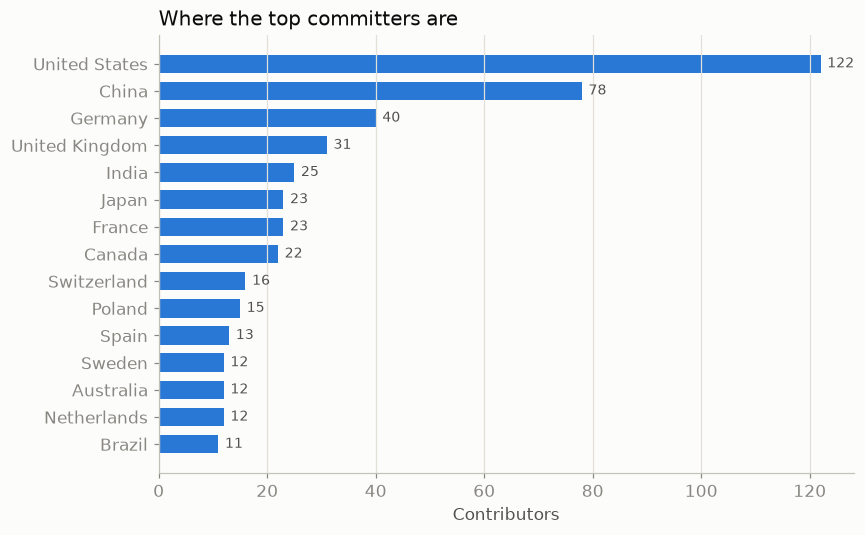

Top 5 countries hold 53% of the resolved contributors.


In [18]:
top = counts.head(15).sort_values("contributors")

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top["country"], top["contributors"], color=BLUE, height=0.68)
for i, (c, v) in enumerate(zip(top["country"], top["contributors"])):
    ax.text(v + max(counts["contributors"]) * 0.01, i, str(v),
            va="center", fontsize=9, color=INK_2)
ax.set_xlabel("Contributors")
ax.set_title("Where the top committers are", loc="left", color=INK, fontsize=13)
ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

print(f"Top 5 countries hold {counts.head(5)['contributors'].sum() / counts['contributors'].sum():.0%} "
      "of the resolved contributors.")

**Ethics note.** Location is personal data. It is aggregated to country level and never
joined back to an individual, and unresolvable entries are dropped rather than guessed —
inferring someone's country from an ambiguous string would manufacture a fact about a
real person.

---
## 6. Machine learning model visualization

The model here is a **measuring instrument, not a product**. It is fitted only to read
off which repository properties carry signal about whether a newcomer's pull request
gets merged.

In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix
from sklearn.model_selection import train_test_split

feats = ["stars", "age_years", "open_issues", "open_prs", "commits_per_week",
         "unique_committers", "gini_commits", "absence_factor",
         "median_issue_response_hrs", "issue_response_rate", "median_pr_review_hrs",
         "gfi_unassigned", "readme_bytes", "has_contributing", "has_ci"]
feats = [f for f in feats if f in repos.columns]

d = prs[prs["is_outsider"] & prs["is_resolved"]].merge(
    repos[["repo"] + feats], on="repo", how="left")
d["log_size"] = np.log1p(d["additions"].fillna(0) + d["deletions"].fillna(0))
d["changed_files"] = pd.to_numeric(d["changed_files"], errors="coerce")

X = d[feats + ["log_size", "changed_files"]].astype(float)
X = X.fillna(X.median())
y = d["is_merged"].astype(int)

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
clf = RandomForestClassifier(n_estimators=300, max_depth=12, min_samples_leaf=15,
                             class_weight="balanced", random_state=42, n_jobs=-1).fit(Xtr, ytr)

proba = clf.predict_proba(Xte)[:, 1]
auc = roc_auc_score(yte, proba)
print(f"n = {len(X):,} resolved outsider PRs   base merge rate = {y.mean():.1%}")
print(f"held-out AUC = {auc:.3f}")

n = 9,178 resolved outsider PRs   base merge rate = 64.3%
held-out AUC = 0.810


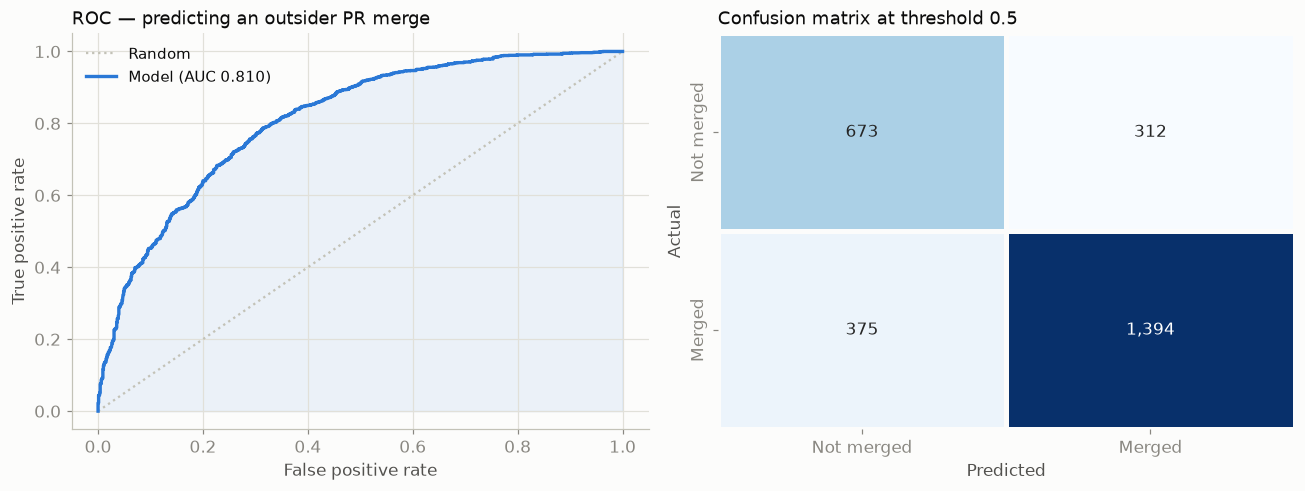

In [20]:
fpr, tpr, _ = roc_curve(yte, proba)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

axes[0].plot([0, 1], [0, 1], color="#c3c2b7", linestyle=":", linewidth=1.5, label="Random")
axes[0].plot(fpr, tpr, color=BLUE, linewidth=2.2, label=f"Model (AUC {auc:.3f})")
axes[0].fill_between(fpr, tpr, alpha=0.08, color=BLUE)
axes[0].set_xlabel("False positive rate"); axes[0].set_ylabel("True positive rate")
axes[0].set_title("ROC — predicting an outsider PR merge", loc="left", color=INK, fontsize=12)
axes[0].legend(frameon=False, fontsize=10)

cm = confusion_matrix(yte, (proba > 0.5).astype(int))
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=axes[1],
            linewidths=2, linecolor=SURFACE,
            xticklabels=["Not merged", "Merged"], yticklabels=["Not merged", "Merged"])
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")
axes[1].set_title("Confusion matrix at threshold 0.5", loc="left", color=INK, fontsize=12)
axes[1].grid(False)
plt.tight_layout(); plt.show()

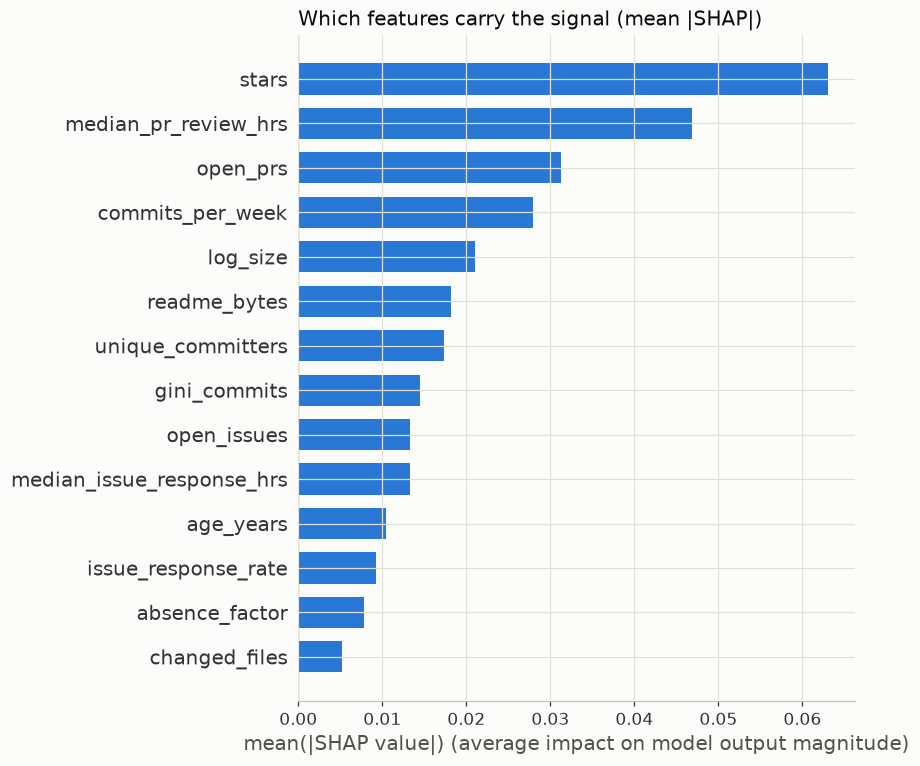

In [21]:
import shap

sample = Xte.sample(min(400, len(Xte)), random_state=42)
explainer = shap.TreeExplainer(clf)
sv = explainer.shap_values(sample)
vals = sv[..., 1] if getattr(sv, "ndim", 2) == 3 else sv

shap.summary_plot(vals, sample, plot_type="bar", show=False, max_display=14,
                  color=BLUE)
plt.title("Which features carry the signal (mean |SHAP|)", loc="left",
          color=INK, fontsize=13)
plt.tight_layout(); plt.show()

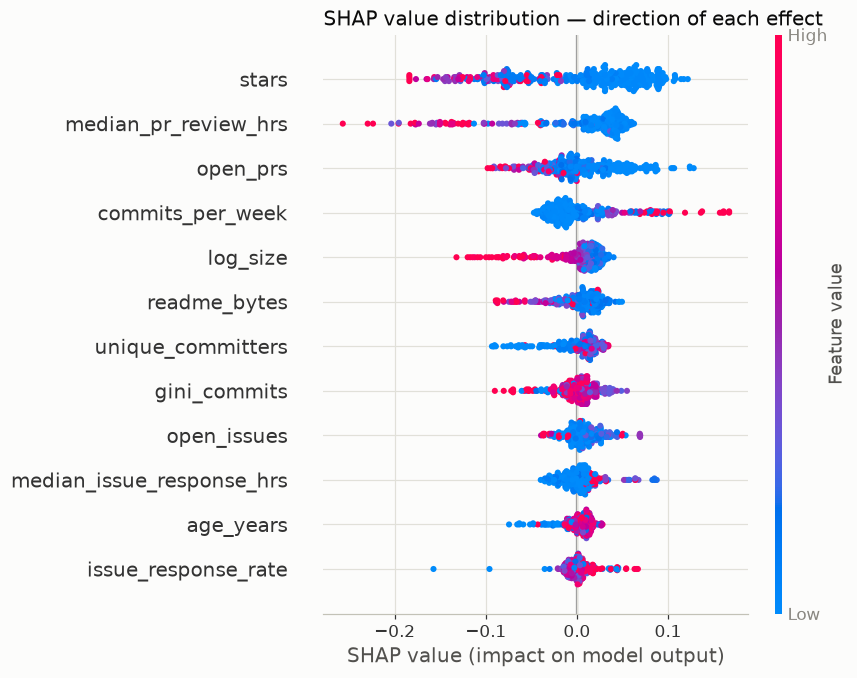

In [22]:
shap.summary_plot(vals, sample, show=False, max_display=12)
plt.title("SHAP value distribution — direction of each effect", loc="left",
          color=INK, fontsize=13)
plt.tight_layout(); plt.show()

**Interpretation, carefully.** SHAP shows *association* within an observational sample.
It does not license a causal claim: "repos with a CONTRIBUTING.md merge more outsider
PRs" is not the same as "adding a CONTRIBUTING.md will get your PR merged". Projects
that write contributing guides likely differ in many unmeasured ways.

### 6.1 Repository archetypes — PCA and t-SNE

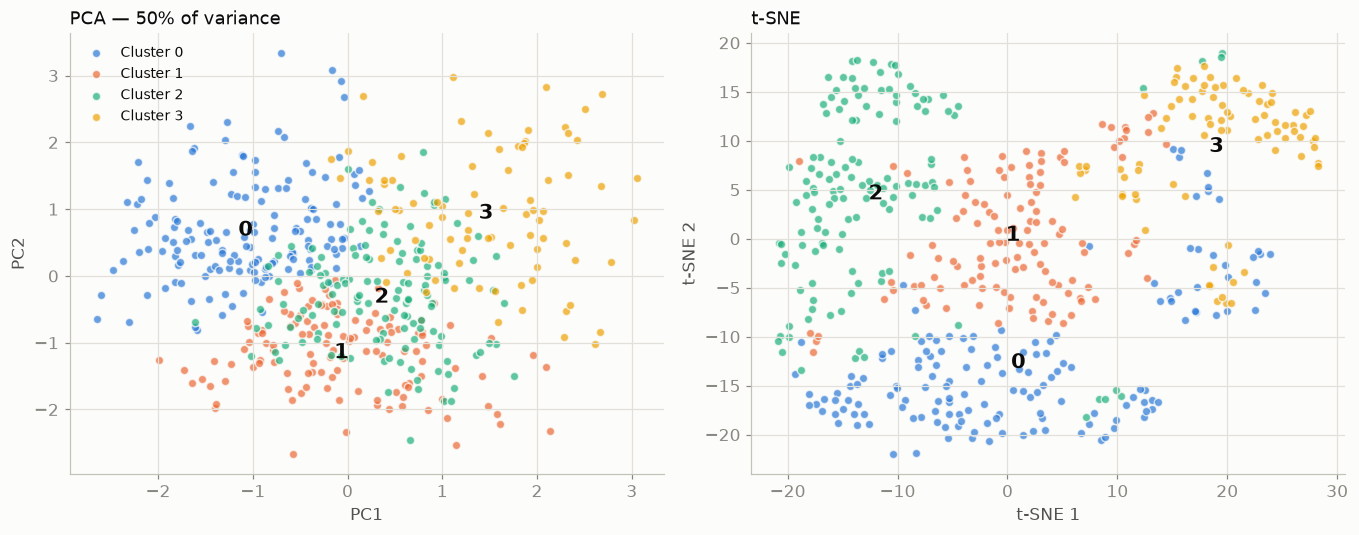

,score_opportunity,score_responsiveness,score_openness,score_activity,score_sustainability,stars,friendliness_index,n
cluster,,,,,,,,
0,48.1,31.8,61.7,30.8,49.5,4931.0,46.8,153
1,48.1,53.8,34.5,51.3,41.0,4995.0,46.0,123
2,46.2,59.3,66.9,67.9,48.7,4947.5,59.2,134
3,82.1,48.7,56.4,62.8,59.6,9347.0,60.4,84


In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

cluster_feats = ["score_opportunity", "score_responsiveness", "score_openness",
                 "score_activity", "score_sustainability"]
C = repos.dropna(subset=cluster_feats).copy()
Z = StandardScaler().fit_transform(C[cluster_feats])

k = 4
C["cluster"] = KMeans(n_clusters=k, n_init=10, random_state=42).fit_predict(Z)

pca = PCA(n_components=2).fit(Z)
pcs = pca.transform(Z)
tsne = TSNE(n_components=2, perplexity=min(30, max(5, len(C) // 4)),
            random_state=42, init="pca").fit_transform(Z)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5))
# Four clusters exceed the three-slot cap for all-pairs colour separation, so
# each cluster is also labelled directly at its centroid.
palette = [BLUE, ORANGE, AQUA, "#eda100"]
for proj, ax, title in [(pcs, axes[0], f"PCA — {pca.explained_variance_ratio_.sum():.0%} of variance"),
                        (tsne, axes[1], "t-SNE")]:
    for c in range(k):
        m = C["cluster"] == c
        ax.scatter(proj[m, 0], proj[m, 1], s=30, color=palette[c], alpha=0.7,
                   edgecolor=SURFACE, linewidth=1, label=f"Cluster {c}")
        ax.annotate(f"{c}", (proj[m, 0].mean(), proj[m, 1].mean()),
                    fontsize=14, fontweight="bold", color=INK,
                    ha="center", va="center")
    ax.set_title(title, loc="left", color=INK, fontsize=12)
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
axes[1].set_xlabel("t-SNE 1"); axes[1].set_ylabel("t-SNE 2")
axes[0].legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

profile = C.groupby("cluster")[cluster_feats + ["stars", "friendliness_index"]].median().round(1)
profile["n"] = C.groupby("cluster").size()
profile

---
## 7. Findings

1. **Stars do not predict a good contributor experience.** Spearman ρ between stars and
   responsiveness is near zero and not significant. The most-starred repository in the
   sample is not the one most likely to answer you.

2. **Outsiders face a large, consistent merge gap.** Insider pull requests merge at a far
   higher rate than outsider ones, and the logistic model shows the gap survives
   controlling for PR size — so it is not simply that newcomers submit worse patches.

3. **Good first issues are scarce.** Only a small minority of active repositories have any
   open, unassigned `good first issue`. The bottleneck for newcomers is availability of
   entry points, not availability of projects.

4. **Bus factor is low.** The median Contributor Absence Factor is very small — in half
   the sample, a tiny group produces most of the commits.

5. **Responsiveness varies significantly by language**, which is why the index ranks
   within language and size bucket rather than globally.

## Limitations

- **Snapshot, not history.** One dated pull; metrics move over time.
- **Recent-window bias.** Commit-based metrics use the most recent 100 commits, so
  `absence_factor` and `unique_committers` understate long-lived projects.
- **Sampling.** Public, non-archived repos above 50 stars in 8 languages — not
  representative of GitHub as a whole, and survivorship bias excludes dead projects.
- **Observational.** Every relationship here is association, not causation.
- **Bot filter is pattern-based.** A bot with an ordinary-looking username survives it.

## Ethics

Repository-level aggregates only. No contributor is ranked, scored, or named in any
output. A low responsiveness score describes an **under-resourced project**, not a
negligent maintainer — most open source is maintained by volunteers with no obligation
to answer anyone. Contributor locations are aggregated to country and never rejoined to
individuals.